# 02 - Laser Diode Thermal Drift and PID Control

This notebook models a laser diode as an electro-optical device coupled to a
first-order thermal package. It shows why industrial laser systems need
temperature control, not just a current driver.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import plotting

plotting.set_style()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from src.laser import LaserDiodeParams, threshold_current, output_power, wavelength, electrical_heat
from src.control import PIDController, simulate_tec_temperature, steady_state_error, overshoot, settling_time

## 1. Engineering Problem

Hold laser output power and wavelength stable while electrical heat and ambient
temperature drift. The design needs to answer:

- How does threshold current move with temperature?
- How much wavelength drift does a package-temperature error create?
- What is the difference between no control, proportional control, and PID?
- When does the TEC hit its authority limit?

## 2. Physical Assumptions

- Threshold current follows `I_th(T) = I_th(T_ref) exp((T - T_ref) / T0)`.
- Optical power follows `P_out = eta_s (I - I_th)` above threshold and zero below.
- Wavelength drift is locally linear: `lambda(T) = lambda_0 + alpha_T (T - T0)`.
- The laser package is a lumped first-order thermal node.
- TEC cooling is represented as a bounded control power.
- Sensor noise and current noise are small perturbations around the operating point.

## 3. System Parameters

In [2]:
params = LaserDiodeParams(
    threshold_current_ref_a=35e-3,
    threshold_reference_temp_k=298.15,
    characteristic_temp_k=55.0,
    slope_efficiency_w_per_a=0.85,
    center_wavelength_m=785e-9,
    wavelength_reference_temp_k=298.15,
    wavelength_temp_coeff_m_per_k=0.28e-9,
    series_voltage_v=2.1,
    thermal_resistance_k_per_w=18.0,
    thermal_capacitance_j_per_k=7.0,
)

pd.DataFrame(
    [
        ("threshold_current_ref_a", params.threshold_current_ref_a, "A", "Threshold current at reference temperature."),
        ("characteristic_temp_k", params.characteristic_temp_k, "K", "Higher T0 means threshold is less temperature-sensitive."),
        ("slope_efficiency_w_per_a", params.slope_efficiency_w_per_a, "W/A", "Incremental optical power above threshold."),
        ("wavelength_temp_coeff_m_per_k", params.wavelength_temp_coeff_m_per_k, "m/K", "Temperature tuning coefficient of diode wavelength."),
        ("series_voltage_v", params.series_voltage_v, "V", "Used to estimate electrical heat load."),
        ("thermal_resistance_k_per_w", params.thermal_resistance_k_per_w, "K/W", "Package-to-ambient thermal resistance."),
        ("thermal_capacitance_j_per_k", params.thermal_capacitance_j_per_k, "J/K", "Thermal inertia; sets response time."),
    ],
    columns=["parameter", "value", "unit", "engineering meaning"],
)

,parameter,value,unit,engineering meaning
0,threshold_current_ref_a,3.500000e-02,A,Threshold current at reference temperature.
1,characteristic_temp_k,5.500000e+01,K,Higher T0 means threshold is less temperature-...
2,slope_efficiency_w_per_a,8.500000e-01,W/A,Incremental optical power above threshold.
3,wavelength_temp_coeff_m_per_k,2.800000e-10,m/K,Temperature tuning coefficient of diode wavele...
4,series_voltage_v,2.100000e+00,V,Used to estimate electrical heat load.
5,thermal_resistance_k_per_w,1.800000e+01,K/W,Package-to-ambient thermal resistance.
6,thermal_capacitance_j_per_k,7.000000e+00,J/K,Thermal inertia; sets response time.


## 4. Simulation Model

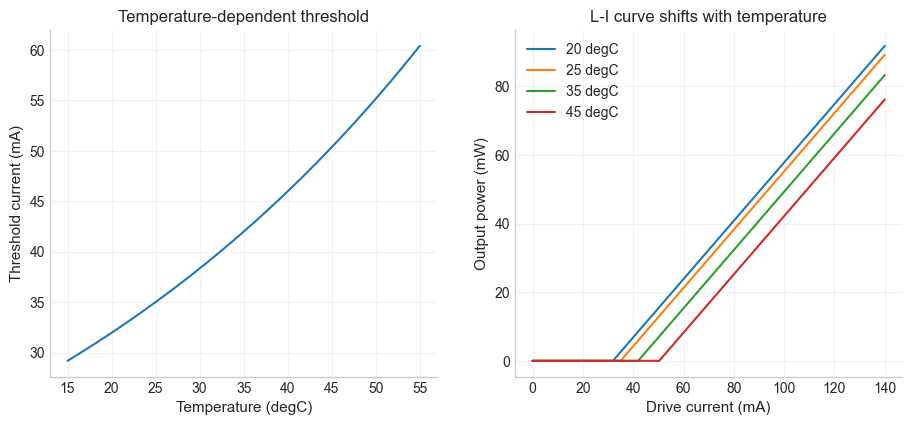

In [3]:
temps_c = np.linspace(15, 55, 200)
temps_k = temps_c + 273.15
currents_ma = np.linspace(0, 140, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(temps_c, threshold_current(temps_k, params) * 1e3)
axes[0].set_xlabel("Temperature (degC)")
axes[0].set_ylabel("Threshold current (mA)")
axes[0].set_title("Temperature-dependent threshold")

for temp_c in [20, 25, 35, 45]:
    p_mw = output_power(currents_ma * 1e-3, temp_c + 273.15, params) * 1e3
    axes[1].plot(currents_ma, p_mw, label=f"{temp_c} degC")
axes[1].set_xlabel("Drive current (mA)")
axes[1].set_ylabel("Output power (mW)")
axes[1].set_title("L-I curve shifts with temperature")
axes[1].legend()
plt.show()

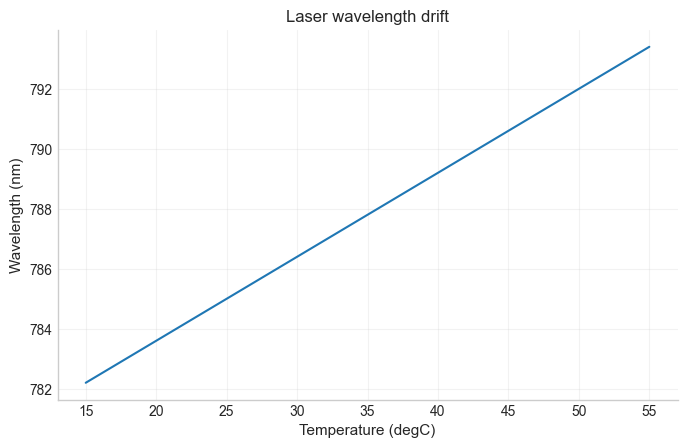

In [4]:
fig, ax = plt.subplots()
ax.plot(temps_c, wavelength(temps_k, params) * 1e9)
ax.set_xlabel("Temperature (degC)")
ax.set_ylabel("Wavelength (nm)")
ax.set_title("Laser wavelength drift")
plt.show()

## 5. Noise / Uncertainty Model

Two small uncertainties are propagated around the operating point:

- current driver noise changes output power through slope efficiency;
- temperature-sensor noise changes both threshold current and wavelength.

This is the kind of quick uncertainty budget that helps decide whether the
dominant problem is the current driver, the TEC loop, or the diode itself.

In [5]:
rng = np.random.default_rng(4)
drive_current_a = 90e-3
nominal_temp_k = 298.15
n = 20_000
current_noise_a = rng.normal(0, 0.15e-3, n)
sensor_noise_k = rng.normal(0, 0.03, n)

p_samples_mw = output_power(drive_current_a + current_noise_a, nominal_temp_k + sensor_noise_k, params) * 1e3
lambda_samples_pm = (wavelength(nominal_temp_k + sensor_noise_k, params) - params.center_wavelength_m) * 1e12

pd.DataFrame(
    {
        "metric": ["output_power_mean_mW", "output_power_std_mW", "wavelength_drift_std_pm"],
        "value": [p_samples_mw.mean(), p_samples_mw.std(), lambda_samples_pm.std()],
    }
)

,metric,value
0,output_power_mean_mW,46.751515
1,output_power_std_mW,0.128515
2,wavelength_drift_std_pm,8.395137


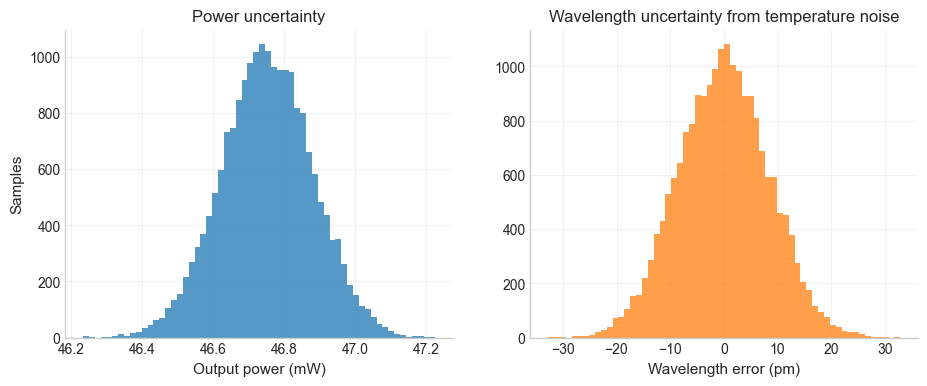

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(p_samples_mw, bins=60, color="tab:blue", alpha=0.75)
axes[0].set_xlabel("Output power (mW)")
axes[0].set_ylabel("Samples")
axes[0].set_title("Power uncertainty")
axes[1].hist(lambda_samples_pm, bins=60, color="tab:orange", alpha=0.75)
axes[1].set_xlabel("Wavelength error (pm)")
axes[1].set_title("Wavelength uncertainty from temperature noise")
plt.show()

## 6. Parameter Scan

The thermal model is:

`C dT/dt = P_heat - P_TEC - (T - T_env) / R_th`.

The controller uses error = measured temperature - setpoint, so positive output
means positive cooling power.

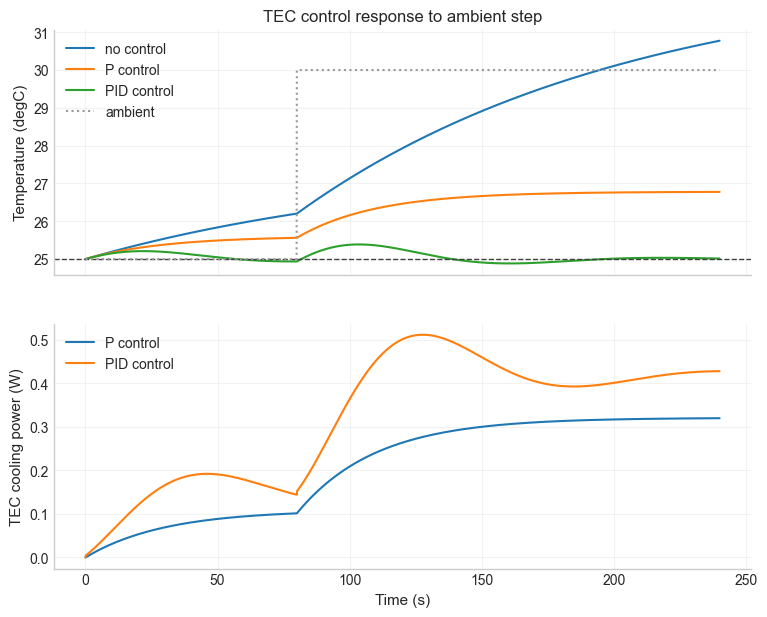

In [7]:
time_s = np.linspace(0, 240, 2401)
setpoint_k = 298.15
env_k = np.where(time_s < 80, 298.15, 303.15)
heat_w = electrical_heat(90e-3, setpoint_k, params)

no_control = simulate_tec_temperature(
    time_s, setpoint_k, env_k, heat_w,
    params.thermal_resistance_k_per_w, params.thermal_capacitance_j_per_k,
    controller=None, initial_temp_k=setpoint_k,
)
p_controller = PIDController(kp=0.18, ki=0.0, kd=0.0, output_limits=(0.0, 2.0))
p_control = simulate_tec_temperature(
    time_s, setpoint_k, env_k, heat_w,
    params.thermal_resistance_k_per_w, params.thermal_capacitance_j_per_k,
    controller=p_controller, initial_temp_k=setpoint_k,
)
pid_controller = PIDController(kp=0.25, ki=0.025, kd=0.2, output_limits=(0.0, 2.0), integral_limits=(-20, 20))
pid_control = simulate_tec_temperature(
    time_s, setpoint_k, env_k, heat_w,
    params.thermal_resistance_k_per_w, params.thermal_capacitance_j_per_k,
    controller=pid_controller, initial_temp_k=setpoint_k,
)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for label, result in [("no control", no_control), ("P control", p_control), ("PID control", pid_control)]:
    axes[0].plot(time_s, result["temperature_k"] - 273.15, label=label)
axes[0].axhline(setpoint_k - 273.15, color="0.25", ls="--", lw=1)
axes[0].plot(time_s, env_k - 273.15, color="0.6", ls=":", label="ambient")
axes[0].set_ylabel("Temperature (degC)")
axes[0].set_title("TEC control response to ambient step")
axes[0].legend()

axes[1].plot(time_s, p_control["control_power_w"], label="P control")
axes[1].plot(time_s, pid_control["control_power_w"], label="PID control")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("TEC cooling power (W)")
axes[1].legend()
plt.show()

In [8]:
summary_rows = []
for label, result in [("no control", no_control), ("P control", p_control), ("PID control", pid_control)]:
    temp = result["temperature_k"]
    summary_rows.append(
        (
            label,
            steady_state_error(temp, setpoint_k),
            overshoot(temp, setpoint_k),
            settling_time(time_s, temp, setpoint_k, tolerance=0.10),
            np.max(result["control_power_w"]),
            (wavelength(temp[-1], params) - wavelength(setpoint_k, params)) * 1e12,
        )
    )

pd.DataFrame(
    summary_rows,
    columns=[
        "case",
        "final_temp_error_K",
        "max_positive_temp_error_K",
        "settling_time_to_0p1K_s",
        "max_TEC_power_W",
        "final_wavelength_error_pm",
    ],
)

,case,final_temp_error_K,max_positive_temp_error_K,settling_time_to_0p1K_s,max_TEC_power_W,final_wavelength_error_pm
0,no control,5.775964,5.775964,NaN,0.000000,1617.269888
1,P control,1.777589,1.777589,NaN,0.319963,497.724961
2,PID control,0.014924,0.387805,170.0,0.511781,4.178629


## 7. Failure Regime

If heat load or ambient temperature requires more cooling than the TEC can
provide, the loop saturates. After that, integral action cannot remove the error;
it can only stay pinned at the actuator limit.

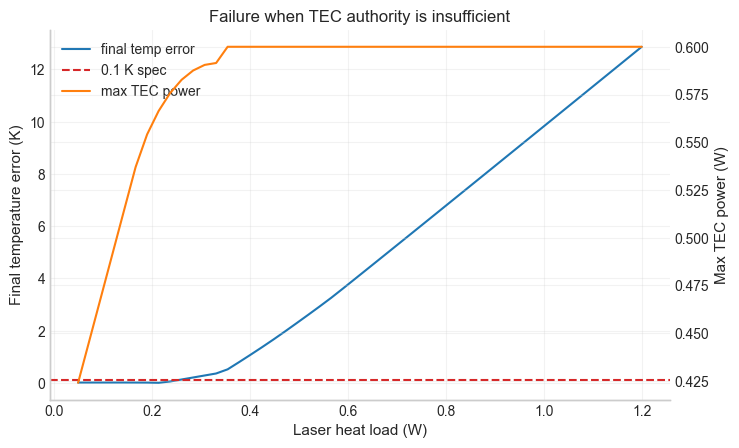

In [9]:
heat_scan = np.linspace(0.05, 1.2, 50)
final_errors = []
max_controls = []
for heat in heat_scan:
    ctrl = PIDController(kp=0.25, ki=0.025, kd=0.1, output_limits=(0.0, 0.6), integral_limits=(-20, 20))
    result = simulate_tec_temperature(
        time_s, setpoint_k, env_k, heat,
        params.thermal_resistance_k_per_w, params.thermal_capacitance_j_per_k,
        controller=ctrl, initial_temp_k=setpoint_k,
    )
    final_errors.append(result["temperature_k"][-1] - setpoint_k)
    max_controls.append(np.max(result["control_power_w"]))

fig, ax1 = plt.subplots()
ax1.plot(heat_scan, final_errors, label="final temp error")
ax1.axhline(0.1, color="tab:red", ls="--", label="0.1 K spec")
ax1.set_xlabel("Laser heat load (W)")
ax1.set_ylabel("Final temperature error (K)")
ax1.set_title("Failure when TEC authority is insufficient")
ax2 = ax1.twinx()
ax2.plot(heat_scan, max_controls, color="tab:orange", label="max TEC power")
ax2.set_ylabel("Max TEC power (W)")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
plt.show()

## 8. Design Trade-Off

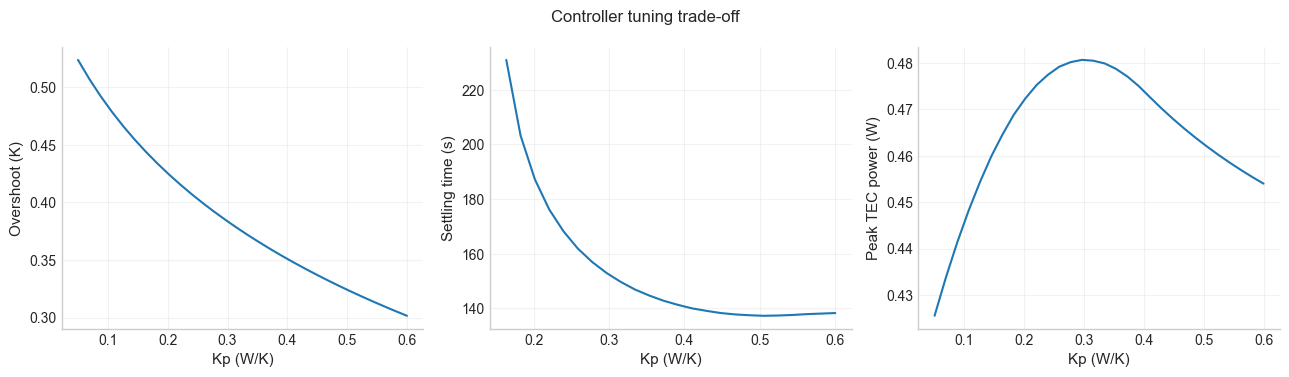

In [10]:
kp_values = np.linspace(0.05, 0.6, 30)
trade_rows = []
for kp in kp_values:
    ctrl = PIDController(kp=kp, ki=0.02, kd=0.05, output_limits=(0.0, 2.0), integral_limits=(-20, 20))
    result = simulate_tec_temperature(
        time_s, setpoint_k, env_k, heat_w,
        params.thermal_resistance_k_per_w, params.thermal_capacitance_j_per_k,
        controller=ctrl, initial_temp_k=setpoint_k,
    )
    temp = result["temperature_k"]
    trade_rows.append((kp, overshoot(temp, setpoint_k), settling_time(time_s, temp, setpoint_k, 0.1), np.max(result["control_power_w"])))

trade = pd.DataFrame(trade_rows, columns=["kp", "overshoot_K", "settling_time_s", "max_TEC_power_W"])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(trade["kp"], trade["overshoot_K"])
axes[0].set_xlabel("Kp (W/K)")
axes[0].set_ylabel("Overshoot (K)")
axes[1].plot(trade["kp"], trade["settling_time_s"])
axes[1].set_xlabel("Kp (W/K)")
axes[1].set_ylabel("Settling time (s)")
axes[2].plot(trade["kp"], trade["max_TEC_power_W"])
axes[2].set_xlabel("Kp (W/K)")
axes[2].set_ylabel("Peak TEC power (W)")
fig.suptitle("Controller tuning trade-off")
plt.tight_layout()
plt.show()

## 9. Key Engineering Conclusions

- Laser threshold current rises exponentially with temperature, so constant
  current does not guarantee constant optical power.
- Wavelength drift can be converted directly from temperature error using the
  diode tuning coefficient; sub-kelvin thermal errors can still matter.
- Proportional control reduces drift but leaves steady-state error under heat
  load and ambient changes.
- Integral action removes steady-state error until the TEC reaches its cooling
  limit.
- Controller tuning is a compromise among settling time, overshoot, noise
  amplification, and actuator headroom.
- A useful laser-system portfolio project should report thermal stability in K,
  wavelength stability in pm, and optical-power stability in mW or percent.